<a href="https://colab.research.google.com/github/Carlos-A-Palomares/mis433/blob/main/customer_churn_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Customer Churn Prediction

## Setup and Imports


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

## Read the Data Files


In [2]:
from google.colab import drive

drive.mount('/content/drive')

data_dir = '/content/drive/MyDrive/churn/'
output_dir = '/content/drive/MyDrive/churn/output/'
os.makedirs(output_dir, exist_ok=True)


Mounted at /content/drive


In [3]:
df_train = pd.read_csv(data_dir + 'churn_train.csv')
df_churn_test = pd.read_csv(data_dir + 'churn_test.csv')
accounts = pd.read_csv(data_dir + 'accounts.csv')
demographics = pd.read_csv(data_dir + 'demographics.csv')
services = pd.read_csv(data_dir + 'services.csv')
sample_submission = pd.read_csv(data_dir + 'sample_submission.csv')

## Describe and Summarize the Data


In [4]:
df_train.head()

,CustomerNo,Churn
0,1201,0
1,1202,0
2,1205,1
3,1206,0
4,1207,0


In [5]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4238 entries, 0 to 4237
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   CustomerNo  4238 non-null   int64
 1   Churn       4238 non-null   int64
dtypes: int64(2)
memory usage: 66.3 KB


In [6]:
df_train['Churn'].value_counts()

,count
Churn,
0,3189
1,1049


In [7]:
df_train['Churn'].value_counts(normalize=True)

,proportion
Churn,
0,0.752478
1,0.247522


In [8]:
accounts.describe(include="all")

,CustomerNo,BaseCharges,DOC,TotalCharges,DOE,ElectronicBilling,ContractType,PaymentMethod
count,5298.000000,5298.000000,5298,5288.000000,5298,5298,5293,5298
unique,NaN,NaN,1,NaN,73,2,3,4
top,NaN,NaN,5-1-2012,NaN,6-Dec-11,Yes,Month-to-month,Electronic check
freq,NaN,NaN,5298,NaN,423,3120,2779,1586
mean,3849.500000,325.467205,NaN,11928.354056,NaN,NaN,NaN,NaN
std,1529.545194,151.352954,NaN,11486.453199,NaN,NaN,NaN,NaN
min,1201.000000,91.250000,NaN,94.250000,NaN,NaN,NaN,NaN
25%,2525.250000,178.250000,NaN,2314.937500,NaN,NaN,NaN,NaN
50%,3849.500000,352.500000,NaN,7377.500000,NaN,NaN,NaN,NaN
75%,5173.750000,451.250000,NaN,19992.812500,NaN,NaN,NaN,NaN


In [9]:
demographics.describe(include="all")

,CustomerNo,Country,State,Retired,HasPartner,HasDependents,Education,Gender
count,5298.000000,5298,5298,5298.000000,5298.000000,5298.000000,5288,5294
unique,NaN,2,2,NaN,NaN,NaN,5,2
top,NaN,India,Maharashtra,NaN,NaN,NaN,Highschool or below,Male
freq,NaN,5293,5290,NaN,NaN,NaN,1426,2656
mean,3849.500000,NaN,NaN,0.158362,1.502454,1.690827,NaN,NaN
std,1529.545194,NaN,NaN,0.365114,0.500041,0.462196,NaN,NaN
min,1201.000000,NaN,NaN,0.000000,1.000000,1.000000,NaN,NaN
25%,2525.250000,NaN,NaN,0.000000,1.000000,1.000000,NaN,NaN
50%,3849.500000,NaN,NaN,0.000000,2.000000,2.000000,NaN,NaN
75%,5173.750000,NaN,NaN,0.000000,2.000000,2.000000,NaN,NaN


In [10]:
services.head()

,CustomerNo,TypeOfService,SeviceDetails
0,1201,DeviceProtection,Yes
1,1201,HasPhoneService,1
2,1201,InternetServiceCategory,Fiber optic
3,1201,MultipleLines,No
4,1201,OnlineBackup,No


## Data Integration: Reshape Services Data


In [11]:
services_wide = services.pivot(
    index='CustomerNo',
    columns='TypeOfService',
    values='SeviceDetails'
).reset_index()

services_wide.head()

TypeOfService,CustomerNo,DeviceProtection,HasPhoneService,InternetServiceCategory,MultipleLines,OnlineBackup,OnlineSecurity,StreamingMovies,StreamingTelevision,TechnicalSupport
0,1201,Yes,1,Fiber optic,No,No,No,Yes,Yes,No
1,1202,No internet service,1,No,No,No internet service,No internet service,No internet service,No internet service,No internet service
2,1203,No,1,Fiber optic,No,No,No,Yes,No,No
3,1204,No,1,DSL,Yes,Yes,Yes,No,No,Yes
4,1205,No,1,Fiber optic,Yes,No,No,No,No,No


## Data Integration: Merge Data Files


In [12]:
df_train_full = pd.merge(df_train, accounts, how='left', on='CustomerNo')
df_train_full = pd.merge(df_train_full, demographics, how='left', on='CustomerNo')
df_train_full = pd.merge(df_train_full, services_wide, how='left', on='CustomerNo')

df_churn_test_full = pd.merge(df_churn_test, accounts, how='left', on='CustomerNo')
df_churn_test_full = pd.merge(df_churn_test_full, demographics, how='left', on='CustomerNo')
df_churn_test_full = pd.merge(df_churn_test_full, services_wide, how='left', on='CustomerNo')

In [13]:
pd.DataFrame({
    'data': ['df_train_full', 'df_churn_test_full'],
    'rows': [df_train_full.shape[0], df_churn_test_full.shape[0]],
    'columns': [df_train_full.shape[1], df_churn_test_full.shape[1]]
})

,data,rows,columns
0,df_train_full,4238,25
1,df_churn_test_full,1060,24


In [14]:
df_train_full.head()

,CustomerNo,Churn,BaseCharges,DOC,TotalCharges,DOE,ElectronicBilling,ContractType,PaymentMethod,Country,...,Gender,DeviceProtection,HasPhoneService,InternetServiceCategory,MultipleLines,OnlineBackup,OnlineSecurity,StreamingMovies,StreamingTelevision,TechnicalSupport
0,1201,0,478.50,5-1-2012,5920.00,10-Jan-11,No,One year,Electronic check,India,...,Male,Yes,1,Fiber optic,No,No,No,Yes,Yes,No
1,1202,0,103.25,5-1-2012,103.25,6-Dec-11,No,Month-to-month,Electronic check,India,...,Male,No internet service,1,No,No,No internet service,No internet service,No internet service,No internet service,No internet service
2,1205,1,372.50,5-1-2012,372.50,6-Dec-11,Yes,Month-to-month,Electronic check,India,...,Female,No,1,Fiber optic,Yes,No,No,No,No,No
3,1206,0,99.50,5-1-2012,6775.50,7-Mar-06,Yes,Two year,Credit card (automatic),India,...,Male,No internet service,1,No,No,No internet service,No internet service,No internet service,No internet service,No internet service
4,1207,0,91.25,5-1-2012,2673.50,17-Sep-09,No,One year,Credit card (automatic),India,...,Male,No internet service,1,No,No,No internet service,No internet service,No internet service,No internet service,No internet service


In [15]:
df_train_full.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4238 entries, 0 to 4237
Data columns (total 25 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   CustomerNo               4238 non-null   int64  
 1   Churn                    4238 non-null   int64  
 2   BaseCharges              4238 non-null   float64
 3   DOC                      4238 non-null   object 
 4   TotalCharges             4230 non-null   float64
 5   DOE                      4238 non-null   object 
 6   ElectronicBilling        4238 non-null   object 
 7   ContractType             4235 non-null   object 
 8   PaymentMethod            4238 non-null   object 
 9   Country                  4238 non-null   object 
 10  State                    4238 non-null   object 
 11  Retired                  4238 non-null   int64  
 12  HasPartner               4238 non-null   int64  
 13  HasDependents            4238 non-null   int64  
 14  Education               

## Create a New Variable


In [16]:
df_train_full['DOC'] = pd.to_datetime(df_train_full['DOC'], format='%m-%d-%Y', errors='coerce')
df_train_full['DOE'] = pd.to_datetime(df_train_full['DOE'], format='%d-%b-%y', errors='coerce')
df_train_full['DaysWithCompany'] = (df_train_full['DOC'] - df_train_full['DOE']).dt.days
df_train_full = df_train_full.drop(columns=['DOC', 'DOE'])

df_churn_test_full['DOC'] = pd.to_datetime(df_churn_test_full['DOC'], format='%m-%d-%Y', errors='coerce')
df_churn_test_full['DOE'] = pd.to_datetime(df_churn_test_full['DOE'], format='%d-%b-%y', errors='coerce')
df_churn_test_full['DaysWithCompany'] = (df_churn_test_full['DOC'] - df_churn_test_full['DOE']).dt.days
df_churn_test_full = df_churn_test_full.drop(columns=['DOC', 'DOE'])

In [17]:
df_train_full[['CustomerNo', 'Churn', 'DaysWithCompany']].head()

,CustomerNo,Churn,DaysWithCompany
0,1201,0,477
1,1202,0,147
2,1205,1,147
3,1206,0,2247
4,1207,0,957


## Exploratory Data Analysis


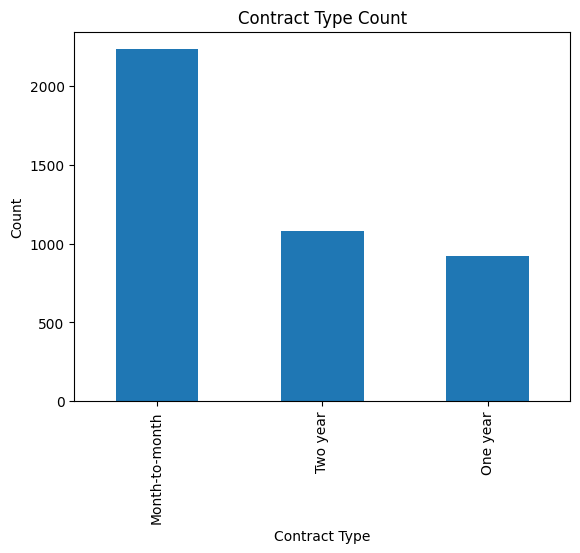

In [18]:
df_train_full['ContractType'].value_counts().plot(kind='bar')
plt.title('Contract Type Count')
plt.xlabel('Contract Type')
plt.ylabel('Count')
plt.show()

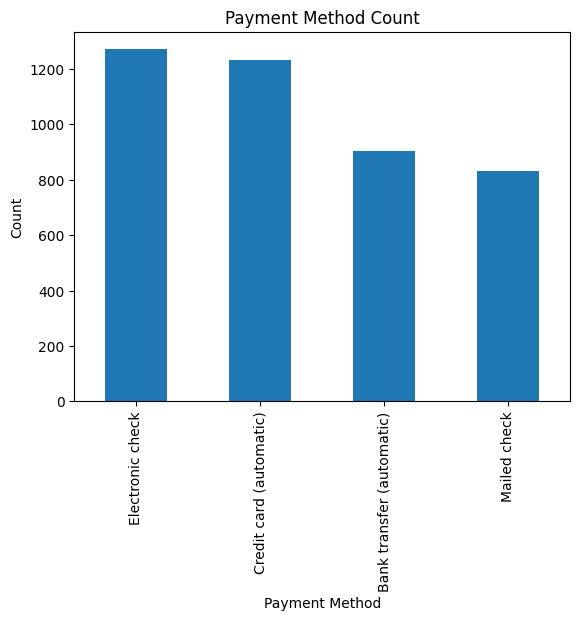

In [19]:
df_train_full['PaymentMethod'].value_counts().plot(kind='bar')
plt.title('Payment Method Count')
plt.xlabel('Payment Method')
plt.ylabel('Count')
plt.show()

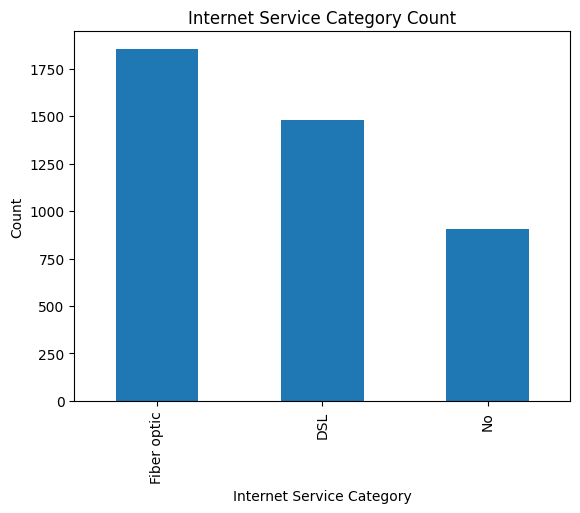

In [20]:
df_train_full['InternetServiceCategory'].value_counts().plot(kind='bar')
plt.title('Internet Service Category Count')
plt.xlabel('Internet Service Category')
plt.ylabel('Count')
plt.show()

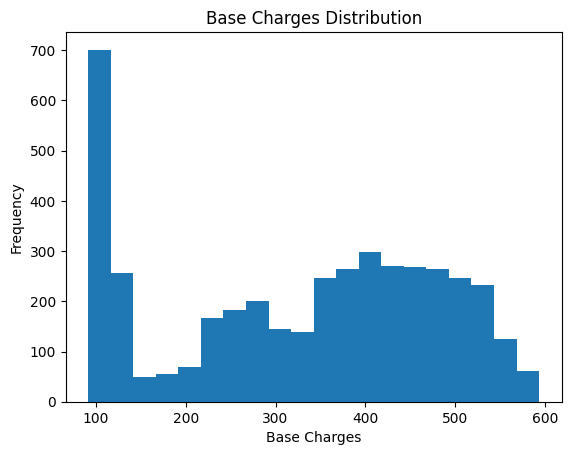

In [21]:
df_train_full['BaseCharges'].plot(kind='hist', bins=20)
plt.title('Base Charges Distribution')
plt.xlabel('Base Charges')
plt.show()

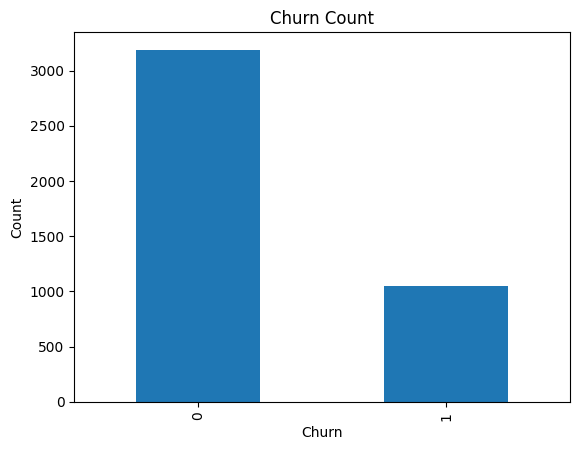

In [22]:
df_train_full['Churn'].value_counts().plot(kind='bar')
plt.title('Churn Count')
plt.xlabel('Churn')
plt.ylabel('Count')
plt.show()

In [23]:
pd.crosstab(df_train_full['ContractType'], df_train_full['Churn'], normalize='index')

Churn,0,1
ContractType,,
Month-to-month,0.589709,0.410291
One year,0.890098,0.109902
Two year,0.972248,0.027752


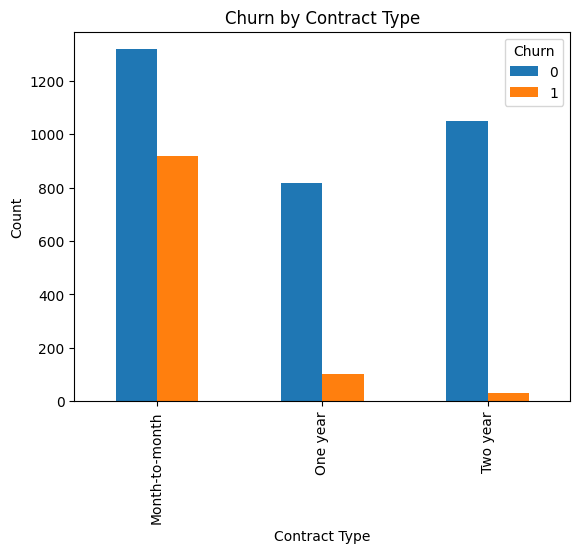

In [24]:
pd.crosstab(df_train_full['ContractType'], df_train_full['Churn']).plot(kind='bar')
plt.title('Churn by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Count')
plt.show()

In [25]:
pd.crosstab(df_train_full['PaymentMethod'], df_train_full['Churn'], normalize='index')

Churn,0,1
PaymentMethod,,
Bank transfer (automatic),0.830752,0.169248
Credit card (automatic),0.848091,0.151909
Electronic check,0.558268,0.441732
Mailed check,0.822329,0.177671


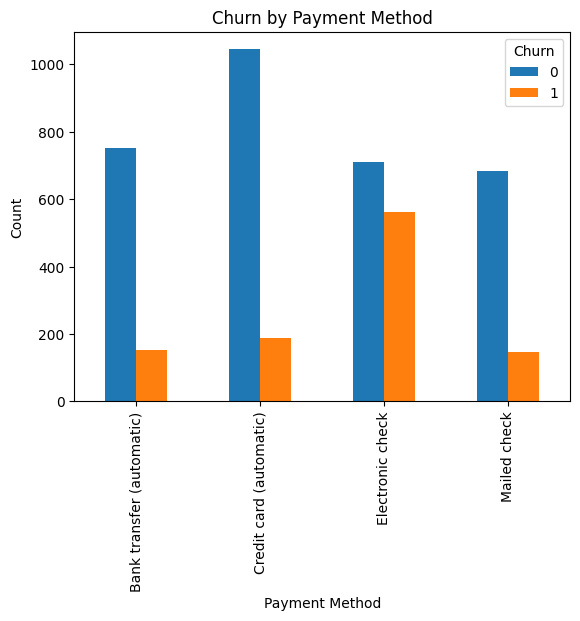

In [26]:
pd.crosstab(df_train_full['PaymentMethod'], df_train_full['Churn']).plot(kind='bar')
plt.title('Churn by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Count')
plt.show()

In [27]:
pd.crosstab(df_train_full['InternetServiceCategory'], df_train_full['Churn'], normalize='index')

Churn,0,1
InternetServiceCategory,,
DSL,0.828938,0.171062
Fiber optic,0.600648,0.399352
No,0.938190,0.061810


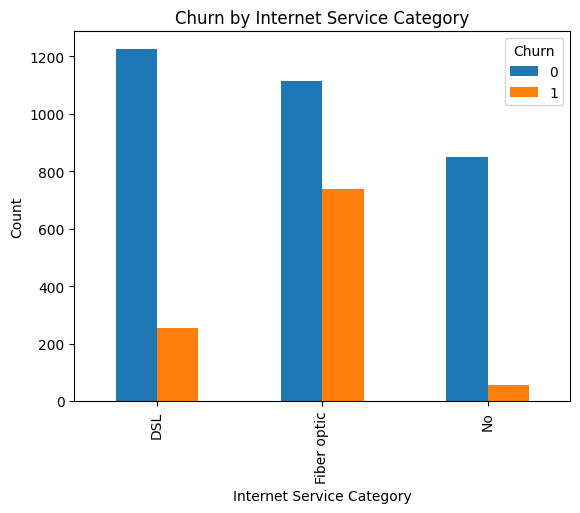

In [28]:
pd.crosstab(df_train_full['InternetServiceCategory'], df_train_full['Churn']).plot(kind='bar')
plt.title('Churn by Internet Service Category')
plt.xlabel('Internet Service Category')
plt.ylabel('Count')
plt.show()

In [29]:
pd.crosstab(df_train_full['TechnicalSupport'], df_train_full['Churn'], normalize='index')

Churn,0,1
TechnicalSupport,,
No,0.606341,0.393659
No internet service,0.938190,0.061810
Yes,0.854914,0.145086


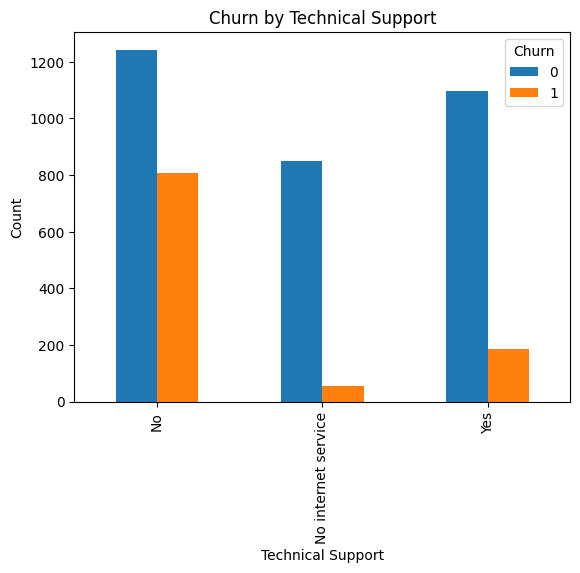

In [30]:
pd.crosstab(df_train_full['TechnicalSupport'], df_train_full['Churn']).plot(kind='bar')
plt.title('Churn by Technical Support')
plt.xlabel('Technical Support')
plt.ylabel('Count')
plt.show()

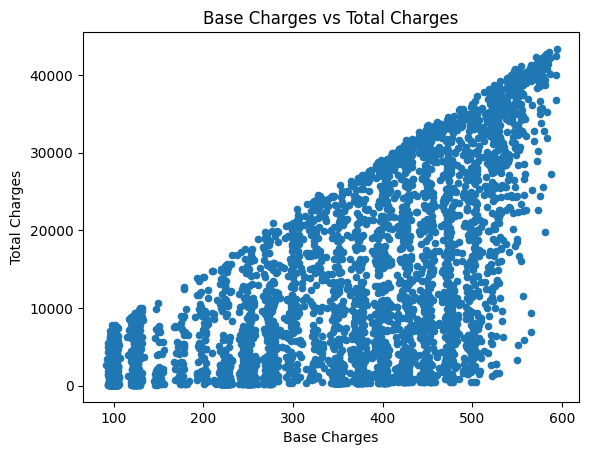

In [31]:
df_train_full.plot(kind='scatter', x='BaseCharges', y='TotalCharges')
plt.title('Base Charges vs Total Charges')
plt.xlabel('Base Charges')
plt.ylabel('Total Charges')
plt.show()

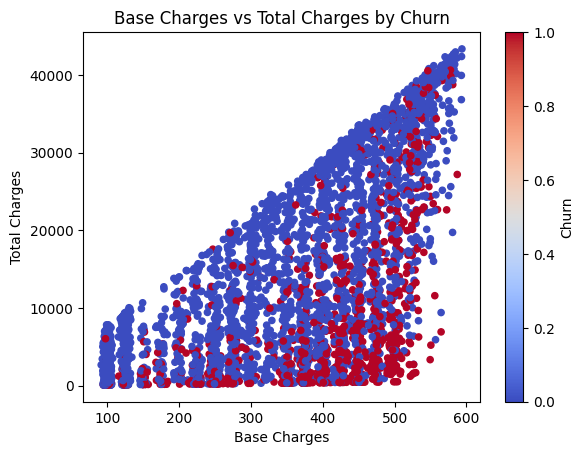

In [59]:
df_train_full.plot(kind="scatter", x="BaseCharges", y="TotalCharges", c="Churn", colormap="coolwarm")
plt.title("Base Charges vs Total Charges by Churn")
plt.xlabel("Base Charges")
plt.ylabel("Total Charges")
plt.show()

## Preprocessing



In [32]:
X = df_train_full.drop(columns=['Churn', 'CustomerNo'])
y = df_train_full['Churn']

X_churn_test = df_churn_test_full.drop(columns=['CustomerNo'])

In [33]:
all_X = pd.concat([X, X_churn_test], axis=0)

for col in all_X.columns:
    if all_X[col].dtype == 'object':
        all_X[col] = all_X[col].fillna(all_X[col].mode()[0])
    else:
        all_X[col] = all_X[col].fillna(all_X[col].median())

all_X = pd.get_dummies(all_X, drop_first=True)

X = all_X.iloc[:len(df_train_full)]
X_churn_test = all_X.iloc[len(df_train_full):]

X.head()

,BaseCharges,TotalCharges,Retired,HasPartner,HasDependents,DaysWithCompany,ElectronicBilling_Yes,ContractType_One year,ContractType_Two year,PaymentMethod_Credit card (automatic),...,OnlineBackup_No internet service,OnlineBackup_Yes,OnlineSecurity_No internet service,OnlineSecurity_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,StreamingTelevision_No internet service,StreamingTelevision_Yes,TechnicalSupport_No internet service,TechnicalSupport_Yes
0,478.50,5920.00,0,2,2,477,False,True,False,False,...,False,False,False,False,False,True,False,True,False,False
1,103.25,103.25,0,2,2,147,False,False,False,False,...,True,False,True,False,True,False,True,False,True,False
2,372.50,372.50,0,2,2,147,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,99.50,6775.50,0,2,2,2247,True,False,True,True,...,True,False,True,False,True,False,True,False,True,False
4,91.25,2673.50,0,2,2,957,False,True,False,True,...,True,False,True,False,True,False,True,False,True,False


In [34]:
X.shape

(4238, 36)

In [35]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Model 1: First Decision Tree



In [36]:
tree1 = DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=42)
tree1.fit(X_train_scaled, y_train)

y_pred1 = tree1.predict(X_test_scaled)
acc1 = accuracy_score(y_test, y_pred1)
acc1

0.7959905660377359

In [37]:
scaler_all = MinMaxScaler()
X_scaled = scaler_all.fit_transform(X)
X_churn_test_scaled = scaler_all.transform(X_churn_test)

tree1.fit(X_scaled, y)
y_hat1 = tree1.predict(X_churn_test_scaled)

submission_model1 = pd.DataFrame({
    'CustomerNo': df_churn_test_full['CustomerNo'],
    'Churn': y_hat1
})

submission_model1.to_csv(output_dir + 'submission_model1.csv', index=False)
submission_model1.head()

,CustomerNo,Churn
0,1203,1
1,1204,0
2,1208,0
3,1220,0
4,1221,0


## Model 2: Increased Tree Depth


In [38]:
tree2 = DecisionTreeClassifier(criterion='entropy', max_depth=5, random_state=42)
tree2.fit(X_train_scaled, y_train)

y_pred2 = tree2.predict(X_test_scaled)
acc2 = accuracy_score(y_test, y_pred2)
acc2

0.8007075471698113

In [39]:
tree2.fit(X_scaled, y)
y_hat2 = tree2.predict(X_churn_test_scaled)

submission_model2 = pd.DataFrame({
    'CustomerNo': df_churn_test_full['CustomerNo'],
    'Churn': y_hat2
})

submission_model2.to_csv(output_dir + 'submission_model2.csv', index=False)
submission_model2.head()

,CustomerNo,Churn
0,1203,0
1,1204,0
2,1208,0
3,1220,0
4,1221,0


## Model 3: Tried Gini


In [40]:
tree3 = DecisionTreeClassifier(criterion='gini', max_depth=7, random_state=42)
tree3.fit(X_train_scaled, y_train)

y_pred3 = tree3.predict(X_test_scaled)
acc3 = accuracy_score(y_test, y_pred3)
acc3

0.7959905660377359

In [41]:
tree3.fit(X_scaled, y)
y_hat3 = tree3.predict(X_churn_test_scaled)

submission_model3 = pd.DataFrame({
    'CustomerNo': df_churn_test_full['CustomerNo'],
    'Churn': y_hat3
})

submission_model3.to_csv(output_dir + 'submission_model3.csv', index=False)
submission_model3.head()

,CustomerNo,Churn
0,1203,0
1,1204,0
2,1208,0
3,1220,0
4,1221,0


## Model 4: Tried Entropy


In [42]:
tree4 = DecisionTreeClassifier(criterion='entropy', max_depth=7, random_state=42)
tree4.fit(X_train_scaled, y_train)

y_pred4 = tree4.predict(X_test_scaled)
acc4 = accuracy_score(y_test, y_pred4)
acc4

0.7983490566037735

In [43]:
tree4.fit(X_scaled, y)
y_hat4 = tree4.predict(X_churn_test_scaled)

submission_model4 = pd.DataFrame({
    'CustomerNo': df_churn_test_full['CustomerNo'],
    'Churn': y_hat4
})

submission_model4.to_csv(output_dir + 'submission_model4.csv', index=False)
submission_model4.head()

,CustomerNo,Churn
0,1203,0
1,1204,0
2,1208,0
3,1220,0
4,1221,0


## Model 5: Tried a Deeper Tree

In [44]:
tree5 = DecisionTreeClassifier(criterion='entropy', max_depth=8, random_state=42)
tree5.fit(X_train_scaled, y_train)

y_pred5 = tree5.predict(X_test_scaled)
acc5 = accuracy_score(y_test, y_pred5)
acc5

0.7889150943396226

In [45]:
tree5.fit(X_scaled, y)
y_hat5 = tree5.predict(X_churn_test_scaled)

submission_model5 = pd.DataFrame({
    'CustomerNo': df_churn_test_full['CustomerNo'],
    'Churn': y_hat5
})

submission_model5.to_csv(output_dir + 'submission_model5.csv', index=False)
submission_model5.head()

,CustomerNo,Churn
0,1203,0
1,1204,0
2,1208,0
3,1220,0
4,1221,0


## Model 6: Tried Depth 6


In [46]:
tree6 = DecisionTreeClassifier(criterion='entropy', max_depth=6, random_state=42)
tree6.fit(X_train_scaled, y_train)

y_pred6 = tree6.predict(X_test_scaled)
acc6 = accuracy_score(y_test, y_pred6)
acc6

0.8136792452830188

In [47]:
tree6.fit(X_scaled, y)
y_hat6 = tree6.predict(X_churn_test_scaled)

submission_model6 = pd.DataFrame({
    'CustomerNo': df_churn_test_full['CustomerNo'],
    'Churn': y_hat6
})

submission_model6.to_csv(output_dir + 'submission_model6.csv', index=False)
submission_model6.head()

,CustomerNo,Churn
0,1203,0
1,1204,0
2,1208,0
3,1220,0
4,1221,0


## Model 7: Used Selected Variables


In [48]:
selected_cols7 = [
    'ContractType',
    'DaysWithCompany',
    'InternetServiceCategory',
    'BaseCharges',
    'TotalCharges',
    'PaymentMethod',
    'Education',
    'StreamingMovies',
    'StreamingTelevision',
    'TechnicalSupport',
    'OnlineBackup',
    'ElectronicBilling',
    'HasDependents',
    'Retired'
]

X7 = df_train_full[selected_cols7]
X7_churn_test = df_churn_test_full[selected_cols7]

In [50]:
selected_cols7

['ContractType',
 'DaysWithCompany',
 'InternetServiceCategory',
 'BaseCharges',
 'TotalCharges',
 'PaymentMethod',
 'Education',
 'StreamingMovies',
 'StreamingTelevision',
 'TechnicalSupport',
 'OnlineBackup',
 'ElectronicBilling',
 'HasDependents',
 'Retired']

In [49]:
all_X7 = pd.concat([X7, X7_churn_test], axis=0)

for col in all_X7.columns:
    if all_X7[col].dtype == 'object':
        all_X7[col] = all_X7[col].fillna(all_X7[col].mode()[0])
    else:
        all_X7[col] = all_X7[col].fillna(all_X7[col].median())

all_X7 = pd.get_dummies(all_X7, drop_first=True)

X7 = all_X7.iloc[:len(df_train_full)]
X7_churn_test = all_X7.iloc[len(df_train_full):]

X7_train, X7_test, y7_train, y7_test = train_test_split(
    X7,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler7 = MinMaxScaler()
X7_train_scaled = scaler7.fit_transform(X7_train)
X7_test_scaled = scaler7.transform(X7_test)

In [51]:
tree7 = DecisionTreeClassifier(criterion='entropy', max_depth=7, random_state=42)
tree7.fit(X7_train_scaled, y7_train)

y_pred7 = tree7.predict(X7_test_scaled)
acc7 = accuracy_score(y7_test, y_pred7)
acc7

0.7983490566037735

In [52]:
scaler7_all = MinMaxScaler()
X7_scaled = scaler7_all.fit_transform(X7)
X7_churn_test_scaled = scaler7_all.transform(X7_churn_test)

tree7.fit(X7_scaled, y)
y_hat7 = tree7.predict(X7_churn_test_scaled)

submission_model7 = pd.DataFrame({
    'CustomerNo': df_churn_test_full['CustomerNo'],
    'Churn': y_hat7
})

submission_model7.to_csv(output_dir + 'submission_model7.csv', index=False)
submission_model7.head()

,CustomerNo,Churn
0,1203,0
1,1204,0
2,1208,0
3,1220,0
4,1221,0


## Model 8: Removed More Variables


In [53]:
selected_cols8 = [
    'ContractType',
    'DaysWithCompany',
    'InternetServiceCategory',
    'BaseCharges',
    'TotalCharges',
    'PaymentMethod',
    'Education',
    'StreamingMovies',
    'StreamingTelevision',
    'TechnicalSupport',
    'OnlineBackup',
    'ElectronicBilling'
]

X8 = df_train_full[selected_cols8]
X8_churn_test = df_churn_test_full[selected_cols8]

In [54]:
selected_cols8

['ContractType',
 'DaysWithCompany',
 'InternetServiceCategory',
 'BaseCharges',
 'TotalCharges',
 'PaymentMethod',
 'Education',
 'StreamingMovies',
 'StreamingTelevision',
 'TechnicalSupport',
 'OnlineBackup',
 'ElectronicBilling']

In [55]:
all_X8 = pd.concat([X8, X8_churn_test], axis=0)

for col in all_X8.columns:
    if all_X8[col].dtype == 'object':
        all_X8[col] = all_X8[col].fillna(all_X8[col].mode()[0])
    else:
        all_X8[col] = all_X8[col].fillna(all_X8[col].median())

all_X8 = pd.get_dummies(all_X8, drop_first=True)

X8 = all_X8.iloc[:len(df_train_full)]
X8_churn_test = all_X8.iloc[len(df_train_full):]

X8_train, X8_test, y8_train, y8_test = train_test_split(
    X8,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler8 = MinMaxScaler()
X8_train_scaled = scaler8.fit_transform(X8_train)
X8_test_scaled = scaler8.transform(X8_test)

In [56]:
tree8 = DecisionTreeClassifier(criterion='entropy', max_depth=7, random_state=42)
tree8.fit(X8_train_scaled, y8_train)

y_pred8 = tree8.predict(X8_test_scaled)
acc8 = accuracy_score(y8_test, y_pred8)
acc8

0.8125

In [57]:
scaler8_all = MinMaxScaler()
X8_scaled = scaler8_all.fit_transform(X8)
X8_churn_test_scaled = scaler8_all.transform(X8_churn_test)

tree8.fit(X8_scaled, y)
y_hat8 = tree8.predict(X8_churn_test_scaled)

submission_model8 = pd.DataFrame({
    'CustomerNo': df_churn_test_full['CustomerNo'],
    'Churn': y_hat8
})

submission_model8.to_csv(output_dir + 'submission_model8.csv', index=False)
submission_model8.head()

,CustomerNo,Churn
0,1203,0
1,1204,0
2,1208,0
3,1220,0
4,1221,0
